<a href="https://colab.research.google.com/github/Dmitze/Dmitze/blob/main/dz_topic_10_DMYTRO_SHYVACHOV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Підходи до покращення якості
ДЗ з порівняння метрики Mutual Information та Feature Importance.

In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import GradientBoostingRegressor

import warnings
warnings.filterwarnings('ignore')

## 1. Завантаження даних
Завантажую дані `autos` із загального файлу.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Шлях до датасету на Google Drive
with open('/content/drive/MyDrive/Colab Notebooks/DZ/mod_05_topic_10_various_data.pkl', 'rb') as f:
    datasets = pickle.load(f)

autos = datasets['autos'].copy()

# Відокремлюємо цільову змінну 'price'
X = autos.copy()
y = X.pop('price')

X.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,...,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,...,4,130,mpfi,3.47,2.68,9,111,5000,21,27
1,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,...,4,130,mpfi,3.47,2.68,9,111,5000,21,27
2,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,65.5,...,6,152,mpfi,2.68,3.47,9,154,5000,19,26
3,audi,gas,std,4,sedan,fwd,front,99.8,176.6,66.2,...,4,109,mpfi,3.19,3.40,10,102,5500,24,30
4,audi,gas,std,4,sedan,4wd,front,99.4,176.6,66.4,...,5,136,mpfi,3.19,3.40,8,115,5500,18,22


## 2. Підготовка ознак
Кодуємо всі категоріальні (текстові) колонки в числа. Також збережемо масив дискретних ознак для `mutual_info_regression`.

In [ ]:
# Знаходимо всі текстові колонки
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# Перекодуємо в числа за допомогою factorize (як в лекції)
for col in cat_features:
    X[col], _ = X[col].factorize()

# Для MI нам треба вказати, які ознаки дискретні
# До категоріальних додаємо num_of_doors та num_of_cylinders
discrete_mask = X.columns.isin(cat_features + ['num_of_doors', 'num_of_cylinders'])

## 3. Mutual Information та 4. Модель
Рахуємо взаємну інформацію. Потім навчаємо регресійну модель `GradientBoostingRegressor`, щоб витягнути з неї `feature_importances_`.

In [ ]:
# 3. Розрахунок MI
mi_scores = mutual_info_regression(X, y, discrete_features=discrete_mask, random_state=42)

# 4. Навчання ансамблю для отримання feature importances
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X, y)
gb_importances = gb_model.feature_importances_

## 5. Масштабування результатів
Оскільки MI та Feature Importance мають різну природу та масштаб, приведемо їх до єдиного формату рангів через `rank(pct=True)`.

In [ ]:
df_scores = pd.DataFrame({
    'Feature': X.columns,
    'MI Scores': mi_scores,
    'GB Scores': gb_importances
})

# Робимо ранкування (значення будуть від 0 до 1, де 1 це найкорисніша ознака)
df_scores['MI Scores'] = df_scores['MI Scores'].rank(pct=True)
df_scores['GB Scores'] = df_scores['GB Scores'].rank(pct=True)

df_scores.sort_values(by='MI Scores', ascending=False).head()

,Feature,MI Scores,GB Scores
11,curb_weight,1.000000,0.956522
14,engine_size,0.956522,1.000000
19,horsepower,0.913043,0.913043
22,highway_mpg,0.869565,0.869565
21,city_mpg,0.826087,0.608696


## 6. Візуалізація результатів
Зробимо графік, щоб порівняти обидві метрики.

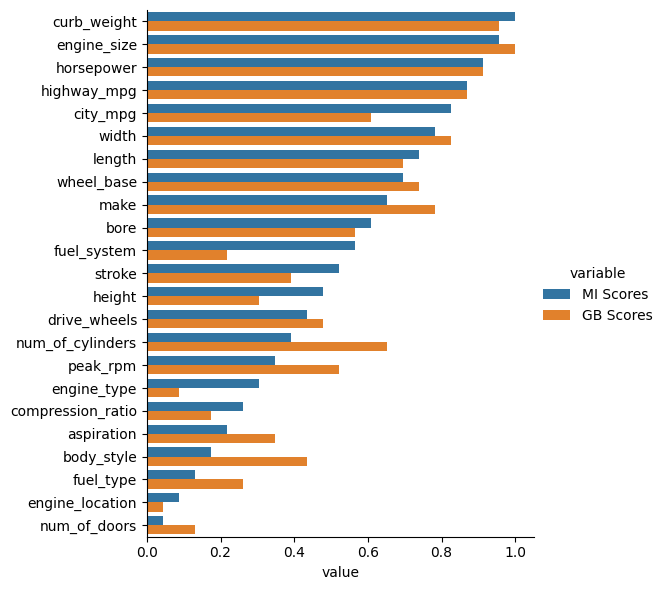

In [ ]:
# Перетворюємо датафрейм у довгий формат (melt) для seaborn
# За замовчуванням melt створить колонки 'variable' та 'value'
df_melted = df_scores.melt(id_vars='Feature')

# Відсортуємо для кращої картинки за спаданням MI Scores
order = df_scores.sort_values('MI Scores', ascending=False)['Feature']

# Будуємо grouped barplot через catplot
sns.catplot(
    data=df_melted,
    kind='bar',
    x='value',
    y='Feature',
    hue='variable',
    order=order,
    height=6,
    aspect=1
)

plt.ylabel('')
plt.show()

## 7. Висновки
Проаналізувавши графік, я можу зробити такі висновки:
1. Розбіжності у важливості: Деякі ознаки можуть мати високий показник MI (наприклад, `curb_weight` має максимальний ранг), але їх важливість у моделі Gradient Boosting відрізняється. Це нормально, бо MI вимірює залежність однієї ознаки з цільовою змінною напряму, а бустінг працює з комбінаціями ознак.
2. Взаємодія ознак: Буває, що фіча сама по собі має середній MI, але модель віддає їй високу важливість. Це через те, що фіча добре працює в парі з якоюсь іншою ппри розбиттях дерева на вузлах.
3. Практичний висновок: MI — це круто для швидкого фільтрування ознак коли їх сотні. Але кінцева важливість все одно залежить від моделі, тому найкраще дивитися на обидві метрики в комплексі.